# Pearls AQI Predictor — Exploratory Data Analysis

This notebook walks through:
1. Loading features from the local feature store
2. Statistical summaries
3. Temporal trend analysis
4. Pollutant correlations
5. AQI distribution analysis
6. Feature importance from trained models
7. SHAP explanations

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime, timedelta

from src.config import DEFAULT_CITY, AQI_LEVELS
from src.feature_pipeline.feature_store import load_features
from src.utils.alerts import classify_aqi, aqi_color

plt.style.use('dark_background')
sns.set_theme(style='darkgrid')
pd.set_option('display.float_format', '{:.2f}'.format)

CITY = DEFAULT_CITY
print(f'City: {CITY}')

City: london


In [2]:
# Load all features from the store
df = load_features(CITY)
print(f'Shape: {df.shape}')
df.head()

Shape: (2112, 53)


,timestamp,ow_aqi,co,no2,o3,so2,pm25,pm10,city,aqi,...,aqi_rolling_min_24h,aqi_rolling_max_24h,aqi_change_1h,aqi_change_3h,aqi_change_24h,aqi_pct_change_1h,aqi_trend,pollutant_sum,pollutant_max,pm_ratio
0,2026-03-06 16:00:00,3,223.77,32.72,8.03,6.20,25.05,25.88,london,78,...,NaN,NaN,NaN,NaN,NaN,NaN,0,321.65,223.77,0.97
1,2026-03-06 17:00:00,2,226.48,35.56,6.84,5.82,23.64,24.39,london,75,...,NaN,NaN,-3.00,NaN,NaN,-0.04,-1,322.73,226.48,0.97
2,2026-03-06 18:00:00,2,228.44,40.33,3.66,5.53,22.15,22.95,london,72,...,NaN,NaN,-3.00,NaN,NaN,-0.04,-1,323.06,228.44,0.97
3,2026-03-06 19:00:00,2,229.49,42.75,3.08,5.44,20.93,22.00,london,70,...,NaN,NaN,-2.00,-8.00,NaN,-0.03,-1,323.69,229.49,0.95
4,2026-03-06 20:00:00,2,230.95,44.10,3.37,5.62,19.97,21.42,london,68,...,NaN,NaN,-2.00,-7.00,NaN,-0.03,-1,325.43,230.95,0.93


In [3]:
# Basic statistics
aqi_cols = ['aqi', 'pm25', 'pm10', 'o3', 'no2', 'so2', 'co',
            'temperature', 'humidity', 'wind_speed']
available = [c for c in aqi_cols if c in df.columns]
df[available].describe()

,aqi,pm25,pm10,o3,no2,so2,co
count,2112.00,2112.00,2112.00,2112.00,2112.00,2112.00,2112.00
mean,33.15,9.10,11.91,85.46,9.52,4.44,140.76
std,39.83,10.60,11.65,25.96,9.39,3.29,27.69
min,2.00,0.50,0.50,0.27,0.99,0.64,99.29
25%,6.00,1.52,3.20,71.31,3.51,2.13,127.05
50%,20.00,4.75,8.30,91.03,6.33,3.83,136.13
75%,55.00,13.54,16.93,102.65,12.25,5.46,145.61
max,500.00,59.84,63.74,194.89,75.35,27.86,303.86


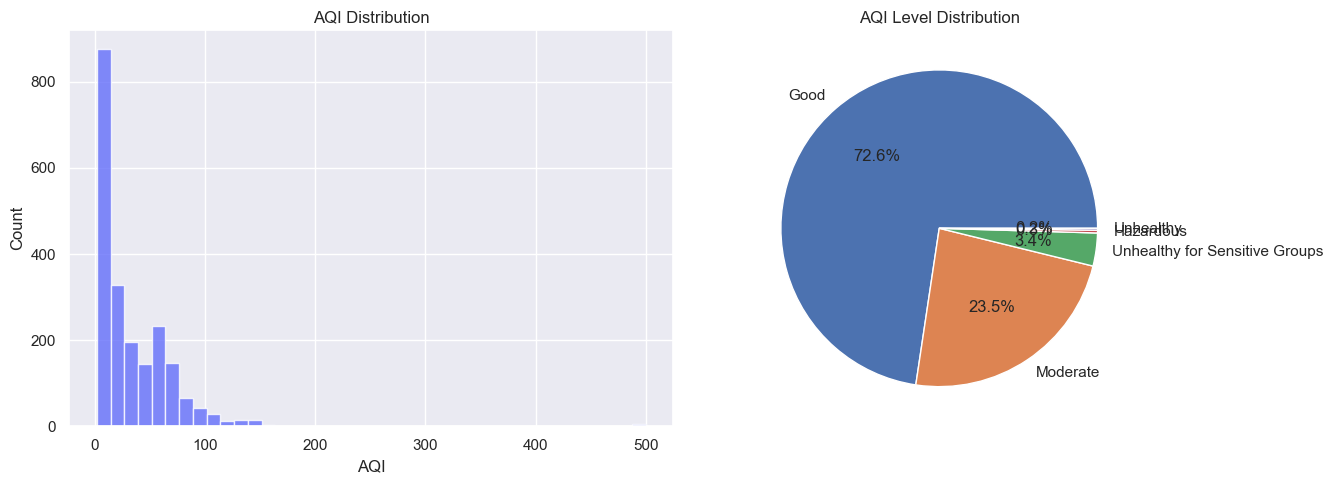

In [4]:
# AQI distribution
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

df['aqi'].hist(bins=40, ax=ax[0], color='#636efa', edgecolor='white', alpha=0.8)
ax[0].set_title('AQI Distribution')
ax[0].set_xlabel('AQI')
ax[0].set_ylabel('Count')

# AQI level pie
if 'aqi' in df.columns:
    df['aqi_level'] = df['aqi'].apply(classify_aqi)
    level_counts = df['aqi_level'].value_counts()
    ax[1].pie(level_counts.values, labels=level_counts.index, autopct='%1.1f%%')
    ax[1].set_title('AQI Level Distribution')

plt.tight_layout()
plt.show()

In [5]:
# Time series: AQI over time
if 'timestamp' in df.columns and 'aqi' in df.columns:
    df['timestamp'] = pd.to_datetime(df['timestamp'])
    fig = px.line(df, x='timestamp', y='aqi',
                  title=f'AQI Over Time — {CITY.title()}',
                  labels={'aqi': 'AQI', 'timestamp': 'Date'},
                  template='plotly_dark')
    fig.add_hline(y=100, line_dash='dot', line_color='yellow',
                  annotation_text='Moderate/Unhealthy threshold')
    fig.add_hline(y=150, line_dash='dot', line_color='orange',
                  annotation_text='Unhealthy threshold')
    fig.show()

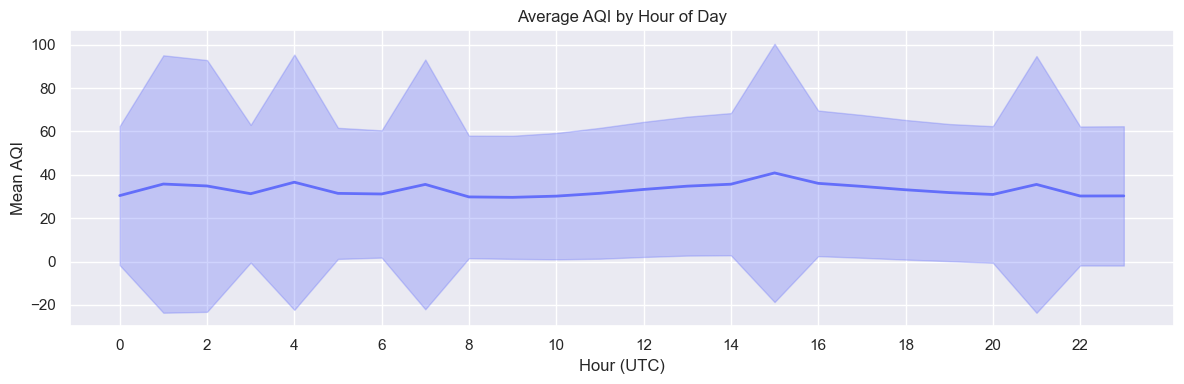

In [6]:
# Hourly AQI pattern (average by hour of day)
if 'hour' in df.columns and 'aqi' in df.columns:
    hourly = df.groupby('hour')['aqi'].agg(['mean', 'std']).reset_index()
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.fill_between(hourly['hour'],
                    hourly['mean'] - hourly['std'],
                    hourly['mean'] + hourly['std'],
                    alpha=0.3, color='#636efa')
    ax.plot(hourly['hour'], hourly['mean'], color='#636efa', lw=2)
    ax.set_title('Average AQI by Hour of Day')
    ax.set_xlabel('Hour (UTC)')
    ax.set_ylabel('Mean AQI')
    ax.set_xticks(range(0, 24, 2))
    plt.tight_layout()
    plt.show()

In [7]:
# Day-of-week pattern
if 'day_of_week' in df.columns and 'aqi' in df.columns:
    days = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    dow = df.groupby('day_of_week')['aqi'].mean().reset_index()
    dow['day_name'] = dow['day_of_week'].map(dict(enumerate(days)))
    fig = px.bar(dow, x='day_name', y='aqi',
                 title='Average AQI by Day of Week',
                 template='plotly_dark',
                 color='aqi', color_continuous_scale='RdYlGn_r')
    fig.show()

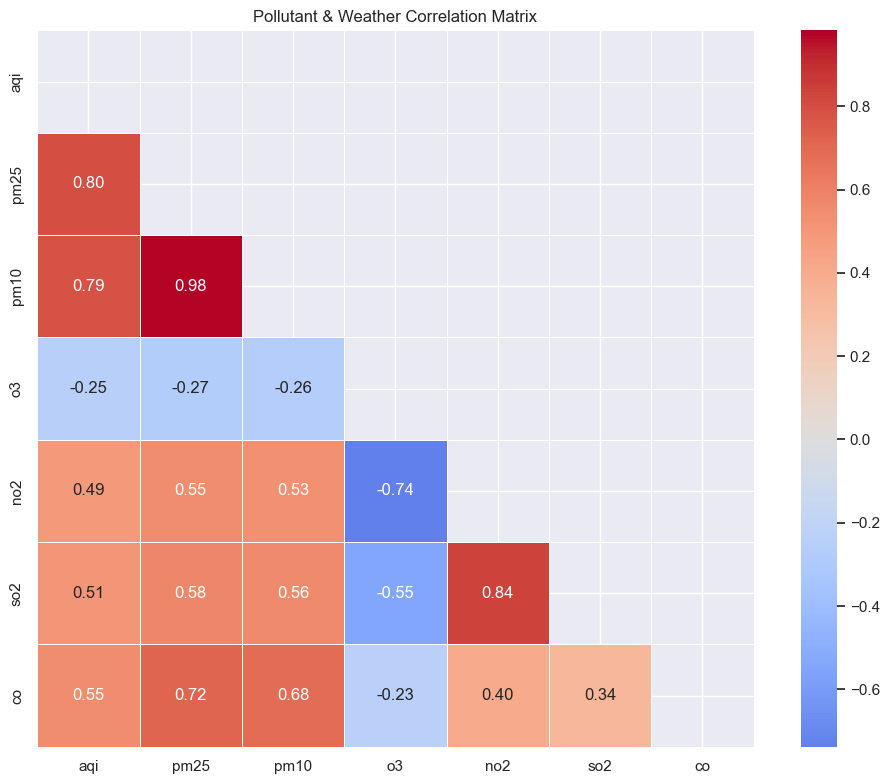

In [8]:
# Correlation heatmap
numeric_cols = [c for c in available if c in df.columns]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', ax=ax,
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
ax.set_title('Pollutant & Weather Correlation Matrix')
plt.tight_layout()
plt.show()

In [9]:
# Wind speed vs AQI
if 'wind_speed' in df.columns and 'aqi' in df.columns:
    fig = px.scatter(df, x='wind_speed', y='aqi',
                     color='aqi', color_continuous_scale='RdYlGn_r',
                     opacity=0.5, trendline='ols',
                     title='Wind Speed vs AQI',
                     template='plotly_dark')
    fig.show()

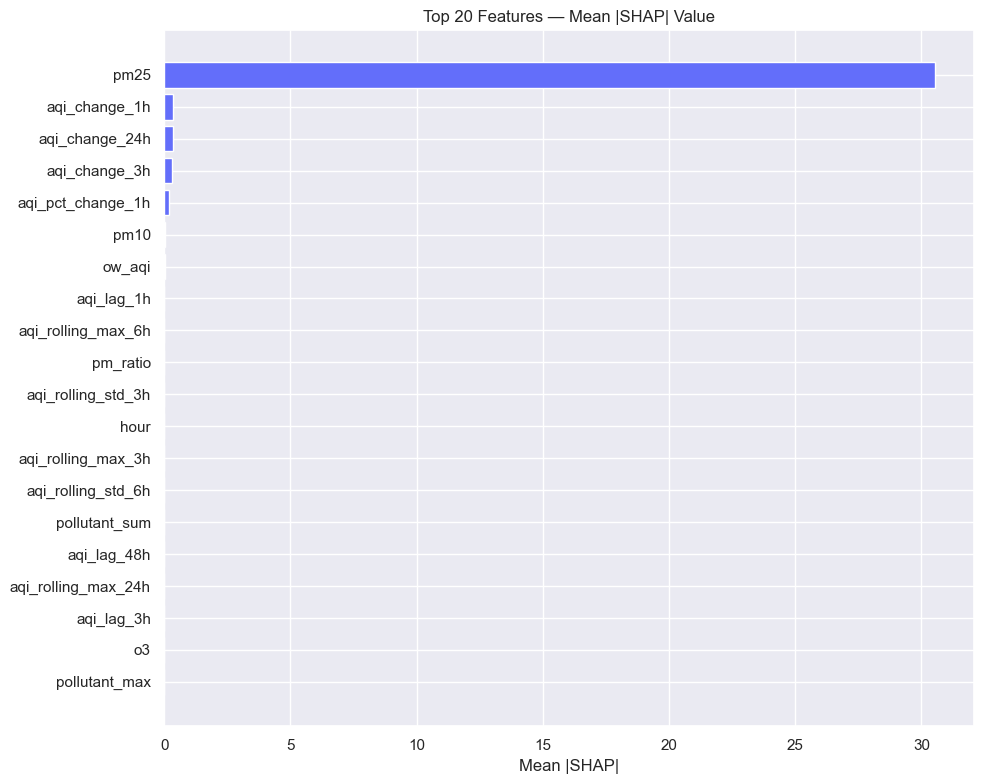

In [10]:
# SHAP feature importance (requires trained model)
try:
    from src.training_pipeline.model_registry import load_model
    from src.feature_pipeline.feature_engineer import get_feature_columns
    from src.utils.shap_explainer import get_shap_summary

    model, meta = load_model(CITY, 'random_forest')
    feature_cols = meta['feature_columns']
    df_clean = df.dropna(subset=feature_cols)
    X = df_clean[feature_cols].values

    shap_df = get_shap_summary(model, X, feature_cols, model_type='tree')
    top20   = shap_df.head(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(top20['feature'][::-1], top20['mean_abs_shap'][::-1], color='#636efa')
    ax.set_title('Top 20 Features — Mean |SHAP| Value')
    ax.set_xlabel('Mean |SHAP|')
    plt.tight_layout()
    plt.show()
except FileNotFoundError:
    print('No trained model found. Run training pipeline first.')
except Exception as e:
    print(f'SHAP analysis skipped: {e}')